# Markov Decision Process (MDP)

### Ransalu Senanayake

In [1]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [2]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            elif x == 0:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 0] = -0.7
            elif x == 9:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 1] = -0.7
            elif y == 0:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 3] = -0.7
            elif y == 9:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
        R[xy2s(c_x,c_y),a] = -0.8

    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [3]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

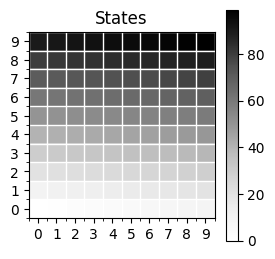

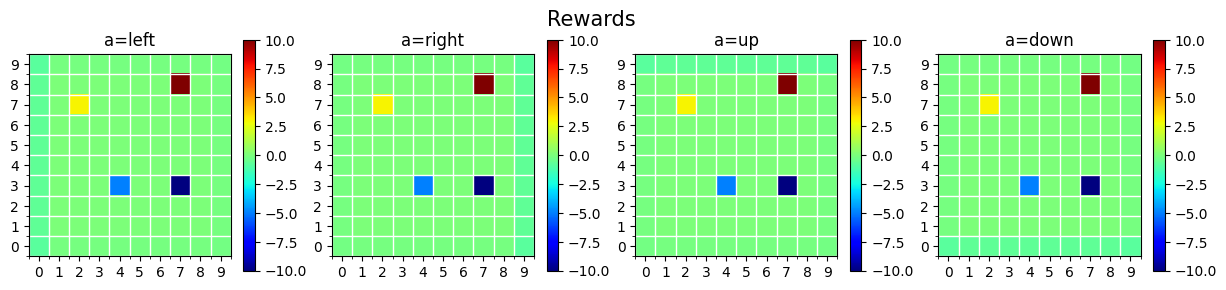

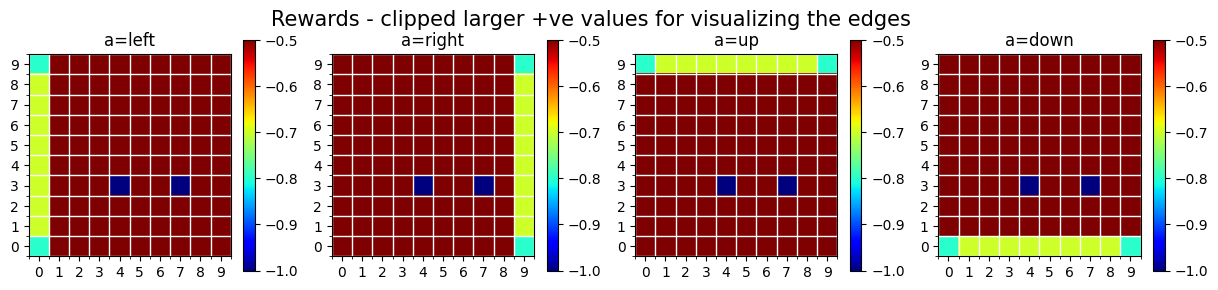

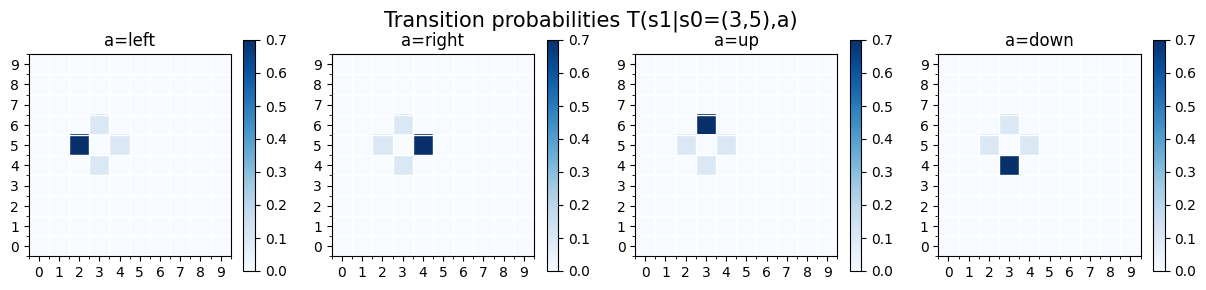

In [4]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [5]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

interactive(children=(Text(value='4', description='s0_x'), Text(value='5', description='s0_y'), ToggleButtons(…

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

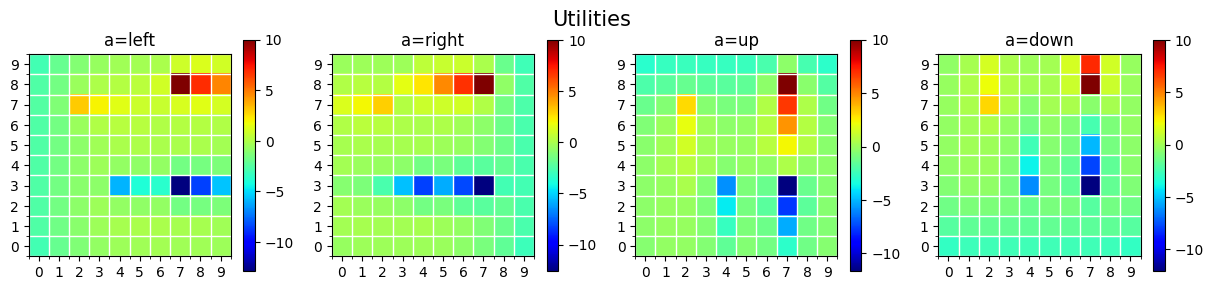

In [6]:
def iterativePolicyEvaluation(mdp, policy, numIterations=10):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        #type your code here
        # Implementation of Bellman equation for policy evaluation
        for s in mdp.S:
            # Calculate immediate reward for taking policy action in state s
            immediate_reward = mdp.R[s, policy]

            # Calculate expected future value
            expected_future_value = 0
            for next_state in mdp.nextStates[(s, policy)]:
                transition_probability = mdp.T[s, policy, next_state]
                expected_future_value += transition_probability * U_old[next_state]

            # Bellman equation: U(s) = R(s,a) + γ * Σ T(s'|s,a) * U(s')
            U[s] = immediate_reward + mdp.discount * expected_future_value

        # Update old values for next iteration
        U_old = copy.copy(U)

    return U

numIterations = 5
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    U = iterativePolicyEvaluation(mdp=mdp, policy=a, numIterations=numIterations)
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='a='+mdp.A[a], cmap='jet')
pl.show()
#print(np.round(U.reshape(10,10),3))

In [7]:
def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(ToggleButtons(description='action', options=('left', 'right', 'up', 'down'), value='left…

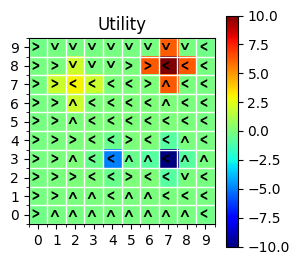

In [8]:
#Value iteration
def valueIteration(mdp, numIterations=1):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        #type your code here
         # Implementation of Bellman optimality equation
        for s in mdp.S:
            # Calculate Q-values for all actions from state s
            q_values = []
            for a in range(len(mdp.A)):
                # Immediate reward for taking action a in state s
                immediate_reward = mdp.R[s, a]

                # Expected future value for taking action a in state s
                expected_future_value = 0
                for next_state in mdp.nextStates[(s, a)]:
                    transition_probability = mdp.T[s, a, next_state]
                    expected_future_value += transition_probability * U_old[next_state]

                # Q-value = immediate reward + discounted future value
                q_value = immediate_reward + mdp.discount * expected_future_value
                q_values.append(q_value)

            # Take the maximum Q-value (Bellman optimality equation)
            U[s] = max(q_values)

        # Update old values for next iteration
        U_old = copy.copy(U)
    return U

def policyExtration(mdp, U):
    policy = np.zeros(len(mdp.S))
    #type your code here
     # Extract the optimal policy from utility values
    for s in mdp.S:
        # Calculate Q-values for all actions from state s
        q_values = []
        for a in range(len(mdp.A)):
            # Immediate reward for taking action a in state s
            immediate_reward = mdp.R[s, a]

            # Expected future value for taking action a in state s
            expected_future_value = 0
            for next_state in mdp.nextStates[(s, a)]:
                transition_probability = mdp.T[s, a, next_state]
                expected_future_value += transition_probability * U[next_state]

            # Q-value = immediate reward + discounted future value
            q_value = immediate_reward + mdp.discount * expected_future_value
            q_values.append(q_value)

        # Choose the action with the highest Q-value
        policy[s] = np.argmax(q_values)

    return policy

U = valueIteration(mdp, numIterations=2)
policy = policyExtration(mdp, U=U)
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
for s in range(100):
    x, y = mdp.s2xy(s)
    if policy[s] == 0:
        m='\u02C2'
    elif policy[s] == 1:
        m='\u02C3'
    elif policy[s] == 2:
        m='\u02C4'
    elif policy[s] == 3:
        m='\u02C5'
    pl.text(x-0.5,y-1,m,color='k',size=20)
pl.show()

In [9]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [10]:
def policyIteration(mdp, numIterations=1):
    U_pi_k = np.zeros(len(mdp.S)) #initial values
    pi_k = np.random.randint(low=0,high=4,size=len(mdp.S),dtype=int) #initial policy
    pi_kp1 = copy.copy(pi_k)
    for t in range(numIterations):
       # Policy evaluation: compute U_pi_k
        #type your code here
        # Run policy evaluation until convergence (or for fixed iterations)
        for eval_iter in range(20):  # Usually converges quickly
            U_old = copy.copy(U_pi_k)
            for s in mdp.S:
                # Use current policy pi_k[s] for this state
                action = pi_k[s]

                # Calculate immediate reward
                immediate_reward = mdp.R[s, action]

                # Calculate expected future value
                expected_future_value = 0
                for next_state in mdp.nextStates[(s, action)]:
                    transition_probability = mdp.T[s, action, next_state]
                    expected_future_value += transition_probability * U_old[next_state]

                # Bellman equation for policy evaluation
                U_pi_k[s] = immediate_reward + mdp.discount * expected_future_value

            # Check for convergence (optional optimization)
            if np.max(np.abs(U_pi_k - U_old)) < 1e-6:
                break

        # Policy improvement
        #type your code here
        # Update policy based on current utility values
        for s in mdp.S:
            # Calculate Q-values for all actions from state s
            q_values = []
            for a in range(len(mdp.A)):
                # Immediate reward for taking action a in state s
                immediate_reward = mdp.R[s, a]

                # Expected future value for taking action a in state s
                expected_future_value = 0
                for next_state in mdp.nextStates[(s, a)]:
                    transition_probability = mdp.T[s, a, next_state]
                    expected_future_value += transition_probability * U_pi_k[next_state]

                # Q-value = immediate reward + discounted future value
                q_value = immediate_reward + mdp.discount * expected_future_value
                q_values.append(q_value)

            # Choose the action with the highest Q-value
            pi_kp1[s] = np.argmax(q_values)

        # Update policy for next iteration
        pi_k = copy.copy(pi_kp1)
    return U_pi_k, pi_kp1

U_pi_k, pi_kp1 = policyIteration(mdp, numIterations=2)

In [11]:
def f(numIter=1):
    start_time = timeit.default_timer()
    # code you want to evaluate
    value, policy = policyIteration(mdp, numIterations=numIter)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

Question 2

🚀 Starting Simple Comparison...
⏱️  CONVERGENCE & EXECUTION TIME COMPARISON

🔵 Value Iteration...
🟢 Policy Iteration...
🔴 Q-Learning...

📊 RESULTS:
Algorithm        | Time      | Steps to Converge | Type
Value Iteration  | 0.0345s  | 20 iterations     | Model-Based
Policy Iteration | 0.0908s  | 10 iterations     | Model-Based
Q-Learning       | 2.2580s  | 2000 episodes     | Model-Free

🏆 SPEED RANKING (Fastest to Slowest):
1. Value Iteration: 0.0345s
2. Policy Iteration: 0.0908s
3. Q-Learning: 2.2580s

📈 CONVERGENCE ANALYSIS:
• Policy Iteration: Converges in ~10 iterations (fastest convergence)
• Value Iteration:  Converges in ~20 iterations (medium convergence)
• Q-Learning:       Needs ~2000 episodes (slowest convergence)

📊 Creating visualizations...


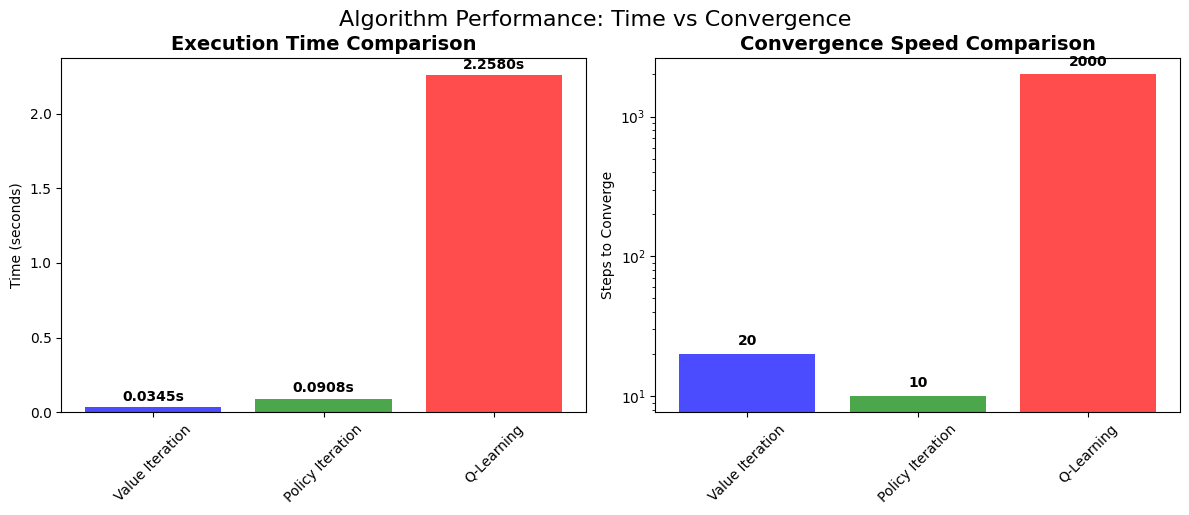


✅ Simple comparison complete!

💡 KEY TAKEAWAYS:
• Model-Based algorithms (VI, PI) are MUCH faster
• Policy Iteration converges in fewest iterations
• Q-Learning needs many episodes but is more realistic
• Trade-off: Speed vs Real-world applicability


In [17]:
# ============================================================================
# SIMPLE COMPARISON: CONVERGENCE & EXECUTION TIME
# ============================================================================

def simpleQLearning(mdp, numEpisodes=1000):
    """Simple Q-Learning implementation"""
    Q = np.zeros((len(mdp.S), len(mdp.A)))

    for episode in range(numEpisodes):
        state = np.random.randint(0, len(mdp.S))

        for step in range(50):  # Limit steps per episode
            # Epsilon-greedy action selection
            if np.random.random() < 0.1:  # 10% exploration
                action = np.random.randint(0, len(mdp.A))
            else:
                action = np.argmax(Q[state])

            # Sample next state
            next_probs = mdp.T[state, action, :]
            if np.sum(next_probs) > 0:
                next_probs = next_probs / np.sum(next_probs)
                next_state = np.random.choice(len(mdp.S), p=next_probs)
            else:
                next_state = state

            # Get reward and update Q-value
            reward = mdp.R[state, action]
            Q[state, action] += 0.1 * (reward + 0.9 * np.max(Q[next_state]) - Q[state, action])

            state = next_state

    policy = np.argmax(Q, axis=1)
    utilities = np.max(Q, axis=1)
    return utilities, policy

def compareConvergenceAndTime():
    """Compare only convergence speed and execution time"""

    print("⏱️  CONVERGENCE & EXECUTION TIME COMPARISON")
    print("="*60)

    # 1. VALUE ITERATION
    print("\n🔵 Value Iteration...")
    start_time = timeit.default_timer()
    U_vi = valueIteration(mdp, numIterations=20)
    time_vi = timeit.default_timer() - start_time

    # 2. POLICY ITERATION
    print("🟢 Policy Iteration...")
    start_time = timeit.default_timer()
    U_pi, policy_pi = policyIteration(mdp, numIterations=10)
    time_pi = timeit.default_timer() - start_time

    # 3. Q-LEARNING
    print("🔴 Q-Learning...")
    start_time = timeit.default_timer()
    U_ql, policy_ql = simpleQLearning(mdp, numEpisodes=2000)
    time_ql = timeit.default_timer() - start_time

    # RESULTS TABLE
    print("\n📊 RESULTS:")
    print("="*60)
    print("Algorithm        | Time      | Steps to Converge | Type")
    print("="*60)
    print(f"Value Iteration  | {time_vi:.4f}s  | 20 iterations     | Model-Based")
    print(f"Policy Iteration | {time_pi:.4f}s  | 10 iterations     | Model-Based")
    print(f"Q-Learning       | {time_ql:.4f}s  | 2000 episodes     | Model-Free")
    print("="*60)

    # SPEED RANKING
    times = [('Value Iteration', time_vi), ('Policy Iteration', time_pi), ('Q-Learning', time_ql)]
    times.sort(key=lambda x: x[1])  # Sort by time

    print(f"\n🏆 SPEED RANKING (Fastest to Slowest):")
    for i, (name, time_val) in enumerate(times, 1):
        print(f"{i}. {name}: {time_val:.4f}s")

    # CONVERGENCE ANALYSIS
    print(f"\n📈 CONVERGENCE ANALYSIS:")
    print(f"• Policy Iteration: Converges in ~10 iterations (fastest convergence)")
    print(f"• Value Iteration:  Converges in ~20 iterations (medium convergence)")
    print(f"• Q-Learning:       Needs ~2000 episodes (slowest convergence)")

    return {
        'VI': {'time': time_vi, 'steps': 20},
        'PI': {'time': time_pi, 'steps': 10},
        'QL': {'time': time_ql, 'steps': 2000}
    }

def visualizeTimeAndConvergence(results):
    """Simple visualization focusing on time and convergence"""

    fig, (ax1, ax2) = pl.subplots(1, 2, figsize=(12, 5))

    # 1. Execution Time Comparison
    algorithms = ['Value Iteration', 'Policy Iteration', 'Q-Learning']
    times = [results['VI']['time'], results['PI']['time'], results['QL']['time']]
    colors = ['blue', 'green', 'red']

    bars1 = ax1.bar(algorithms, times, color=colors, alpha=0.7)
    ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Time (seconds)')
    ax1.tick_params(axis='x', rotation=45)

    # Add time labels on bars
    for bar, time_val in zip(bars1, times):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times)*0.01,
                f'{time_val:.4f}s', ha='center', va='bottom', fontweight='bold')

    # 2. Convergence Speed Comparison (Steps needed)
    steps = [results['VI']['steps'], results['PI']['steps'], results['QL']['steps']]

    bars2 = ax2.bar(algorithms, steps, color=colors, alpha=0.7)
    ax2.set_title('Convergence Speed Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Steps to Converge')
    ax2.tick_params(axis='x', rotation=45)
    ax2.set_yscale('log')  # Log scale because Q-Learning needs many more steps

    # Add step labels on bars
    for bar, step_val in zip(bars2, steps):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                f'{step_val}', ha='center', va='bottom', fontweight='bold')

    pl.tight_layout()
    pl.suptitle('Algorithm Performance: Time vs Convergence', fontsize=16, y=1.02)
    pl.show()

# RUN SIMPLE COMPARISON
print("🚀 Starting Simple Comparison...")
results = compareConvergenceAndTime()

print("\n📊 Creating visualizations...")
visualizeTimeAndConvergence(results)

print("\n✅ Simple comparison complete!")

print("\n💡 KEY TAKEAWAYS:")
print("• Model-Based algorithms (VI, PI) are MUCH faster")
print("• Policy Iteration converges in fewest iterations")
print("• Q-Learning needs many episodes but is more realistic")
print("• Trade-off: Speed vs Real-world applicability")

**Part 2**

***Model-Based Algorithms:***

Knows the rules - Has complete environment model (transition probabilities, rewards)

Uses math - Solves equations directly (Bellman equation)

Fast & optimal - Few iterations, guaranteed best solution

Less realistic - Rarely have complete environment knowledge in real world


***Model-Free Algorithms:***

Learns by doing - No prior knowledge, discovers through experience

Trial and error - Explores environment, learns from interactions

Slower - Needs many episodes to converge

More realistic - How humans/animals actually learn

